In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree, Delaunay
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

# ---- Global variables ----
GENES = ['CDH5', 'PECAM1', 'COL1A1', 'COL1A2', 'PDGFRB', 'VWF', 'DLL4', 'MMP1', 'SEMA3F', 'FLT1', 'ICAM1', 'JAG1', 'KDR', 'VEGFA', 'ITGA6', 'PDGFB', 'ANGPT2', 'APLN']
IMAGE_KEY = "source_folder"          # one physical image per source_folder
output_dir = Path(".")

# Cell-type ordering / colours (capitalised labels, matching part1/part3).
CT_ORDER = ["Endothelial", "Fibroblast", "Unknown", "Zero Reads"]
CT_COLORS = {"Endothelial": "#d62728", "Fibroblast": "#1f77b4", "Unknown": "#7f7f7f", "Zero Reads": "#cccccc"}

# Neighbourhood-analysis parameters.
K_SPATIAL = 15                       # neighbours used for the Moran KNN-smoothing (Sections 3/4)
RADIUS_UM = 30.0                     # Delaunay edge cutoff (um) defining a cell's neighbours + local density
NICHE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1", "COL1A1", "COL1A2", "PDGFRB"}

# Gene-module parameters (Section 4).
MODULE_LINEAGE = "Endothelial"       # dominant population the modules describe
MIN_ON = 20                          # each gene ON in >= this many cells (stable odds ratio)
MODULE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1"}
TIME_ORDER = ["6h", "day1", "day2", "day4"]

all_data = pd.read_csv(output_dir / "clustered_data_with_states.csv")
X = all_data[list(GENES)].astype(int).to_numpy()

# Cluster co-location z-score matrix from part 3.
z_all = pd.read_csv(output_dir / "cluster_colocation_zscores.csv", index_col=0)

# Rebuild the gene-state cluster metadata from the saved per-cell "group" label
# (group = cluster name for clustered cells, else "unknown" / "no reads").
clustered_cells = all_data[all_data["bmm"] >= 0]
cluster_ids = np.sort(clustered_cells["bmm"].unique())
cluster_name_of = clustered_cells.groupby("bmm")["group"].first().to_dict()
cluster_names = [cluster_name_of[c] for c in cluster_ids]
all_order = cluster_names + ["unknown", "no reads"]

# Gene-state cluster colours (grey for unknown / no-reads).
cluster_cmap = plt.get_cmap("tab10", len(cluster_names))
cluster_palette = {name: to_rgba(cluster_cmap(i)) for i, name in enumerate(cluster_names)}
cluster_palette["unknown"] = to_rgba("0.55")
cluster_palette["no reads"] = to_rgba("0.82")


In [2]:
def timepoint_of(name):
    """Map an image / source_folder name to a timepoint bin (6h / day1 / day2 / day4)."""
    s = str(name).lower().replace(" ", "")
    if "6h" in s:                                  return "6h"
    if "day4" in s or re.search(r"d4(?!\d)", s):   return "day4"
    if "day2" in s or re.search(r"d2(?!\d)", s):   return "day2"
    if "day1" in s or re.search(r"d1(?!\d)", s):   return "day1"
    return "unknown"


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**

In [10]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from its
# Delaunay neighbours *within the same image*, keeping only edges shorter than RADIUS_UM.
# Delaunay + a physical-distance cutoff is more biologically plausible than a fixed k: each
# cell is linked to the cells it actually touches/faces, the neighbour count adapts to local
# density, and long convex-hull edges are pruned. The x_um/y_um/z_um coordinates are already
# in physical microns (z-spacing differs from xy), so Euclidean distance here is
# anisotropy-correct and the same cutoff means the same physical scale in every direction.
#   - cell-type composition   (% endo/fibro/no reads/unknown  CT_ORDER)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of Delaunay neighbours within RADIUS_UM)
celltype_onehot = (pd.get_dummies(all_data["cell_type"])
                   .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

def delaunay_neighbour_edges(coords, cutoff):
    """Undirected Delaunay edges (local indices) with Euclidean length <= cutoff (physical um)."""
    if len(coords) < 4:                                            # too few points for a 3D triangulation
        pairs = np.array(list(combinations(range(len(coords)), 2)), dtype=int).reshape(-1, 2)
    else:
        simplices = Delaunay(coords, qhull_options="QJ").simplices  # QJ joggles to survive coplanar/degenerate points
        pairs = np.vstack([simplices[:, [i, j]]
                           for i in range(simplices.shape[1]) for j in range(i + 1, simplices.shape[1])])
        pairs = np.unique(np.sort(pairs, axis=1), axis=0)
    if len(pairs) == 0:
        return pairs.reshape(0, 2)
    lengths = np.linalg.norm(coords[pairs[:, 0]] - coords[pairs[:, 1]], axis=1)
    return pairs[lengths <= cutoff]

neighbour_celltype_fraction = np.zeros((len(all_data), len(CT_ORDER)))
neighbour_gene_fraction = np.zeros((len(all_data), len(GENES)))
neighbour_entropy = np.zeros(len(all_data))
local_density = np.zeros(len(all_data))

for image_name, sub in all_data.groupby(IMAGE_KEY):
    cell_positions = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    edges = delaunay_neighbour_edges(coords, RADIUS_UM)
    local_onehot = celltype_onehot[cell_positions]                                        # this image, local order
    local_X = X[cell_positions]
    # Symmetric edge list so every neighbour relation is counted from both endpoints.
    src = np.concatenate([edges[:, 0], edges[:, 1]]).astype(int)
    dst = np.concatenate([edges[:, 1], edges[:, 0]]).astype(int)
    degree = np.bincount(src, minlength=len(sub))
    ct_sum = np.zeros((len(sub), len(CT_ORDER)))
    gene_sum = np.zeros((len(sub), len(GENES)))
    np.add.at(ct_sum, src, local_onehot[dst])                                             # sum neighbour one-hots per cell
    np.add.at(gene_sum, src, local_X[dst])
    safe_degree = np.where(degree > 0, degree, 1)[:, None]                                # isolated cells -> zero vectors
    composition = ct_sum / safe_degree
    neighbour_celltype_fraction[cell_positions] = composition
    neighbour_gene_fraction[cell_positions] = gene_sum / safe_degree
    neighbour_entropy[cell_positions] = -np.sum(
        np.where(composition > 0, composition * np.log(composition), 0.0), axis=1)
    # Pure cell density: every cell within RADIUS_UM (exclude self), independent of the Delaunay graph.
    local_density[cell_positions] = cKDTree(coords).query_ball_point(coords, RADIUS_UM, return_length=True) - 1
neighbourhood = pd.DataFrame(neighbour_celltype_fraction,
                             columns=[f"nb_pct{ct}" for ct in CT_ORDER], index=all_data.index)
neighbourhood = pd.concat(
    [neighbourhood,
     pd.DataFrame(neighbour_gene_fraction, columns=[f"nb_{gene}" for gene in GENES], index=all_data.index)],
    axis=1)
neighbourhood["nb_entropy"] = neighbour_entropy
neighbourhood["nb_density"] = local_density
all_data[neighbourhood.columns] = neighbourhood
print(neighbourhood.columns)


Index(['nb_pctEndothelial', 'nb_pctFibroblast', 'nb_pctUnknown',
       'nb_pctZero Reads', 'nb_CDH5', 'nb_PECAM1', 'nb_COL1A1', 'nb_COL1A2',
       'nb_PDGFRB', 'nb_VWF', 'nb_DLL4', 'nb_MMP1', 'nb_SEMA3F', 'nb_FLT1',
       'nb_ICAM1', 'nb_JAG1', 'nb_KDR', 'nb_VEGFA', 'nb_ITGA6', 'nb_PDGFB',
       'nb_ANGPT2', 'nb_APLN', 'nb_entropy', 'nb_density'],
      dtype='object')


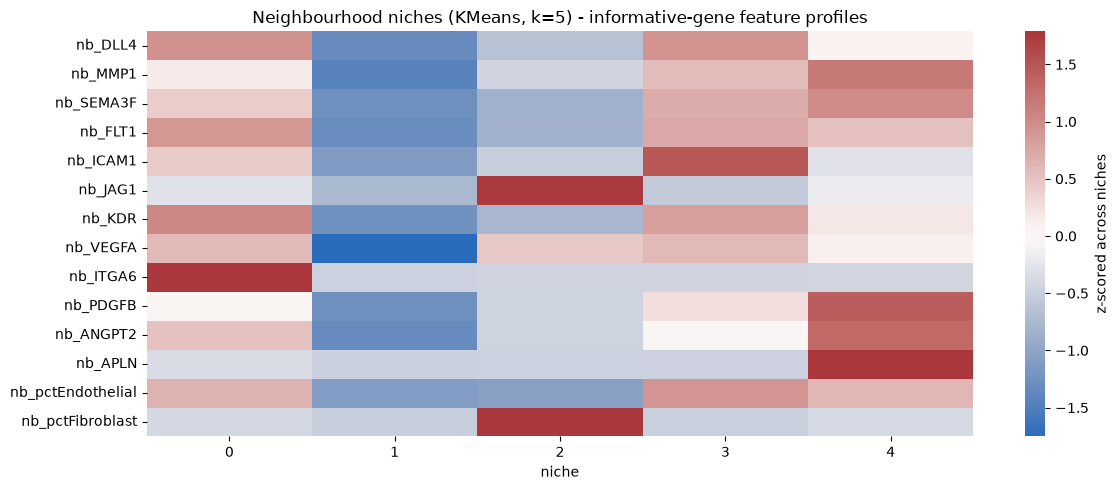

In [11]:
# Cluster the NEIGHBOURHOODS into recurring micro-environments ("niches"). The population
# is overwhelmingly endothelial, so cell-type composition, its Shannon entropy and the
# lineage-defining markers dominate any clustering that includes them - niches then collapse
# onto an uninteresting endothelial-density axis. We therefore build niches from the
# NEIGHBOURHOOD EXPRESSION of the informative (non-marker) genes only.
N_NICHES = 5
niche_genes = [g for g in GENES if g not in NICHE_MARKER_EXCLUDE]
nb_feature_cols = [f"nb_{g}" for g in niche_genes]  +  ['nb_pctEndothelial'] + ['nb_pctFibroblast']# + ['nb_pctUnknown'] + ["nb_density"] 
Zf = StandardScaler().fit_transform(all_data[nb_feature_cols].values)

all_data["niche"] = KMeans(n_clusters=N_NICHES, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche (z-scored across niches so genes and density are comparable).
niche_profile = all_data.groupby("niche")[nb_feature_cols].mean()
niche_profile_z = (niche_profile - niche_profile.mean()) / (niche_profile.std() + 1e-9)
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile_z.T, cmap="vlag", center=0,
            cbar_kws={"label": "z-scored across niches"})
plt.title(f"Neighbourhood niches (KMeans, k={N_NICHES}) - informative-gene feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()


In [5]:
all_data["niche"].value_counts().sort_index()

niche
0     442
1    6239
2     909
3    5116
4     341
Name: count, dtype: int64

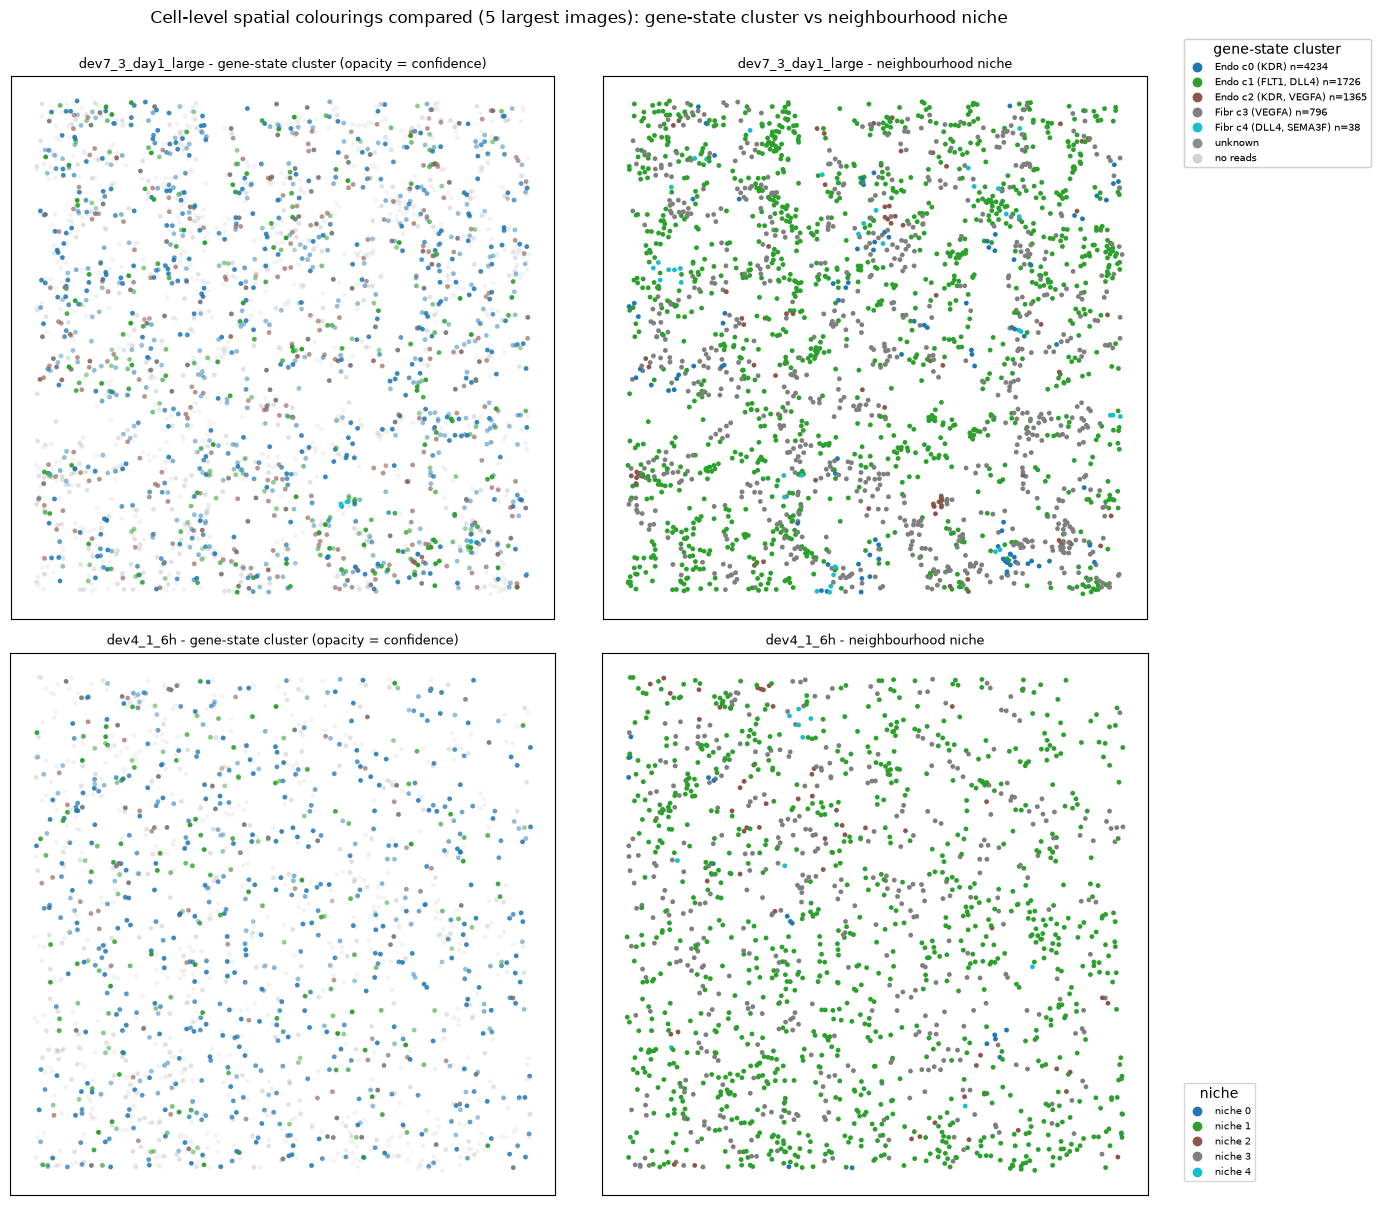

In [6]:
# Compare two per-cell spatial colourings on the largest images: gene-state cluster vs niche.
niche_ids = np.sort(all_data["niche"].unique())
niche_cmap = plt.get_cmap("tab10", len(niche_ids))
niche_color = {nid: niche_cmap(i) for i, nid in enumerate(niche_ids)}

top_images = all_data[IMAGE_KEY].value_counts().head(2).index.tolist()
fig, axes = plt.subplots(len(top_images), 2, figsize=(12, 6 * len(top_images)), squeeze=False)
for row, image_name in enumerate(top_images):
    sub = all_data[all_data[IMAGE_KEY] == image_name]

    rgba = np.array([cluster_palette[g] for g in sub["group"]])
    conf = sub["bmm_confidence"].to_numpy(dtype=float)
    rgba[:, 3] = np.where(np.isnan(conf), 0.25, np.clip(conf, 0.05, 1.0))  # opacity = confidence
    axes[row, 0].scatter(sub["x_um"], sub["y_um"], s=12, c=rgba, edgecolors="none")
    axes[row, 0].set_title(f"{image_name} - gene-state cluster (opacity = confidence)", fontsize=9)

    axes[row, 1].scatter(sub["x_um"], sub["y_um"], s=12, edgecolors="none",
                         c=[niche_color[n] for n in sub["niche"]])
    axes[row, 1].set_title(f"{image_name} - neighbourhood niche", fontsize=9)

    for col in (0, 1):
        axes[row, col].set_aspect("equal"); axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

cluster_handles = [Line2D([0], [0], marker="o", linestyle="", color=cluster_palette[name], label=name)
                   for name in all_order]
niche_handles = [Line2D([0], [0], marker="o", linestyle="", color=niche_color[nid], label=f"niche {nid}")
                 for nid in niche_ids]
leg1 = fig.legend(handles=cluster_handles, title="gene-state cluster", fontsize=7,
                  loc="upper left", bbox_to_anchor=(1.0, 0.98))
fig.add_artist(leg1)
fig.legend(handles=niche_handles, title="niche", fontsize=7,
           loc="lower left", bbox_to_anchor=(1.0, 0.02))
fig.suptitle("Cell-level spatial colourings compared (5 largest images): "
             "gene-state cluster vs neighbourhood niche", y=1.0)
plt.tight_layout(); plt.show()


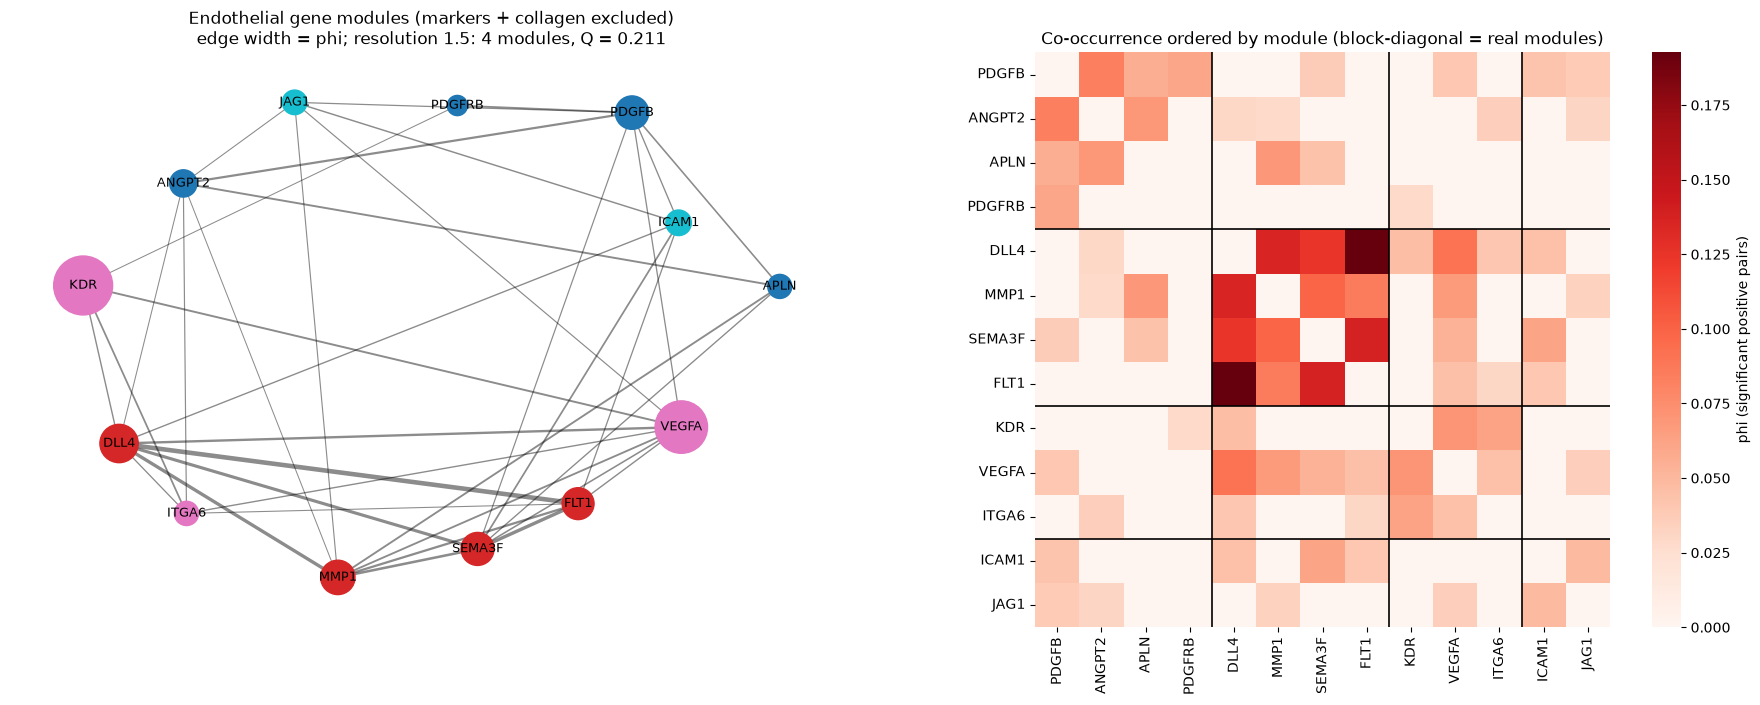

Endothelial gene modules (phi, resolution 1.5): 4 modules, Q = 0.211
  mod 0: PDGFB, ANGPT2, APLN: PDGFB, ANGPT2, APLN, PDGFRB
  mod 1: DLL4, MMP1, SEMA3F: DLL4, MMP1, SEMA3F, FLT1
  mod 2: KDR, VEGFA, ITGA6: KDR, VEGFA, ITGA6
  mod 3: ICAM1, JAG1: ICAM1, JAG1


In [12]:
# ===== SECTION 4: ENDOTHELIAL GENE MODULES =====
# Co-occurrence graph on endothelial cells: exclude pan-endothelial markers + collagen, take the
# greedy-modularity partition. Edge weight choice sets the module count: phi (Matthews correlation)
# keeps the perivascular genes merged -> 4 modules; log2 odds ratio splits them into a mural
# (PDGFB/PDGFRB) and a remodelling (ANGPT2/APLN) module -> 5. We use phi here for the 4-module split.
MODULE_RESOLUTION = 1.5
MODULE_WEIGHT = "phi"                        # phi -> 4 modules; log2_OR -> 5 (splits perivascular)
MODULE_GENES = [g for g in GENES if g not in MODULE_MARKER_EXCLUDE | {"COL1A1", "COL1A2"}]

Bm = all_data[(all_data["cell_type"] == MODULE_LINEAGE) & all_data["has_reads"]][MODULE_GENES].to_numpy()
on_count, on_freq = Bm.sum(0), Bm.mean(0)

rows = []
for i in range(len(MODULE_GENES)):
    for j in range(i + 1, len(MODULE_GENES)):
        a = int(((Bm[:, i] == 1) & (Bm[:, j] == 1)).sum())
        b, c = int(on_count[i]) - a, int(on_count[j]) - a
        d = len(Bm) - a - b - c
        fisher_stat, p = fisher_exact([[a, b], [c, d]])
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
        phi = (a * d - b * c) / denom if denom else 0.0        # Matthews correlation of the two 0/1 vectors
        rows.append((MODULE_GENES[i], MODULE_GENES[j], np.log2(odds), phi, p, int(on_count[i]), int(on_count[j])))
gp = pd.DataFrame(rows, columns=["g1", "g2", "log2_OR", "phi", "pvalue", "n1", "n2"])
gp["FDR"] = multipletests(gp.pvalue, method="fdr_bh")[1]
pos = gp[(gp.log2_OR > 0) & (gp.FDR < 0.05) & (gp.n1 >= MIN_ON) & (gp.n2 >= MIN_ON)].copy()

Gg = nx.Graph(); Gg.add_nodes_from(MODULE_GENES)
for r in pos.itertuples():
    Gg.add_edge(r.g1, r.g2, weight=float(getattr(r, MODULE_WEIGHT)))
communities = list(nx.community.greedy_modularity_communities(Gg, weight="weight", resolution=MODULE_RESOLUTION))
Q = nx.community.modularity(Gg, communities, weight="weight")
module_of = {g: m for m, com in enumerate(communities) for g in com}
n_mod = len(communities)

# Short label per module (top-3 genes by ON-frequency) reused by every downstream cell.
module_labels = {m: f"mod {m}: {', '.join(sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)])[:3])}"
                 for m, com in enumerate(communities)}

# --- graph (edge width = weight) + module-ordered co-occurrence heatmap ---
mcmap = plt.get_cmap("tab10", max(n_mod, 1))
conn = [g for g in Gg.nodes() if Gg.degree(g) > 0]
Hs = Gg.subgraph(conn)
lay = nx.spring_layout(Hs, weight="weight", k=1.4, seed=1)
nsz = [200 + 1600 * on_freq[MODULE_GENES.index(g)] / on_freq.max() for g in Hs.nodes()]
ncol = [mcmap(module_of[g]) for g in Hs.nodes()]
ew = np.array([Hs[u][v]["weight"] for u, v in Hs.edges()]); ew = 0.3 + 3.0 * ew / ew.max()

fig, axg = plt.subplots(1, 2, figsize=(18, 7))
nx.draw_networkx_edges(Hs, lay, ax=axg[0], width=ew, alpha=0.45)
nx.draw_networkx_nodes(Hs, lay, ax=axg[0], node_size=nsz, node_color=ncol)
nx.draw_networkx_labels(Hs, lay, ax=axg[0], font_size=9)
axg[0].set_title(f"{MODULE_LINEAGE} gene modules (markers + collagen excluded)\n"
                 f"edge width = {MODULE_WEIGHT}; resolution {MODULE_RESOLUTION}: {n_mod} modules, Q = {Q:.3f}")
axg[0].axis("off")

order = [g for com in communities for g in sorted(com, key=lambda x: -on_freq[MODULE_GENES.index(x)])]
Mh = pd.DataFrame(0.0, index=order, columns=order)
for r in pos.itertuples():
    w = float(getattr(r, MODULE_WEIGHT))
    Mh.loc[r.g1, r.g2] = w; Mh.loc[r.g2, r.g1] = w
sns.heatmap(Mh, cmap="Reds", square=True, ax=axg[1], cbar_kws={"label": f"{MODULE_WEIGHT} (significant positive pairs)"})
for bnd in np.cumsum([len(c) for c in communities])[:-1]:
    axg[1].axhline(bnd, color="k", lw=1.2); axg[1].axvline(bnd, color="k", lw=1.2)
axg[1].set_title("Co-occurrence ordered by module (block-diagonal = real modules)")
plt.tight_layout(); plt.show()

print(f"{MODULE_LINEAGE} gene modules ({MODULE_WEIGHT}, resolution {MODULE_RESOLUTION}): {n_mod} modules, Q = {Q:.3f}")
for m, com in enumerate(communities):
    print(f"  {module_labels[m]}: {', '.join(sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)]))}")
isolated = [g for g in MODULE_GENES if Gg.degree(g) == 0]
if isolated:
    print(f"  no significant positive partner: {', '.join(isolated)}")


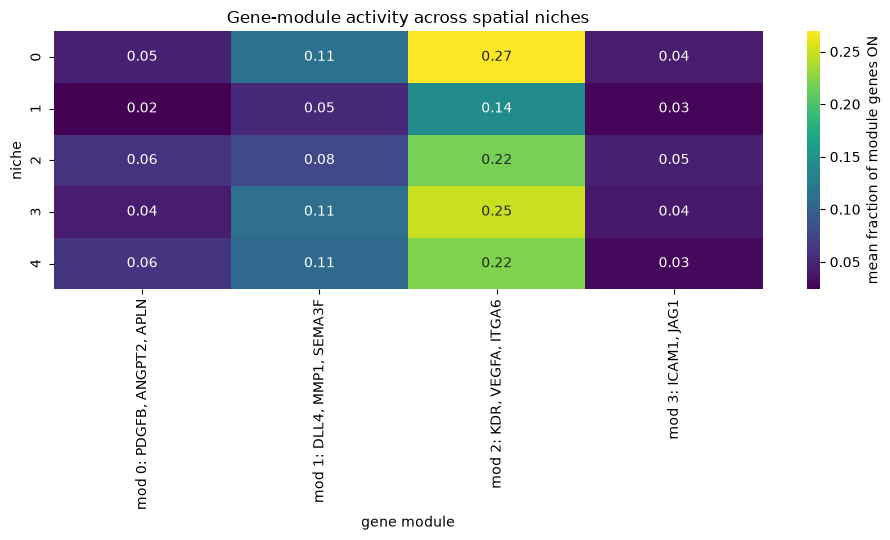

In [13]:
# GENE-MODULE ACTIVITY PER NICHE. For every cell, the fraction of each module's genes
# that are ON; averaged per niche -> which co-firing gene programmes are active where.
module_activity = pd.DataFrame(
    {module_labels[m]: all_data[list(com)].mean(axis=1) for m, com in enumerate(communities)})
module_activity["niche"] = all_data["niche"].to_numpy()
niche_module = module_activity.groupby("niche").mean()

plt.figure(figsize=(1.4 * len(communities) + 4, 0.5 * all_data["niche"].nunique() + 3))
sns.heatmap(niche_module, cmap="viridis", annot=True, fmt=".2f",
            cbar_kws={"label": "mean fraction of module genes ON"})
plt.title("Gene-module activity across spatial niches")
plt.xlabel("gene module"); plt.ylabel("niche")
plt.tight_layout(); plt.show()


[knn] dev7_3_day1_large: 2350 cells, 21410 edges
    mod 0: PDGFB, ANGPT2, APLN         I=+0.033 p=0.005  patches=  4 max=   1 (frac 0.25)  -> intermixed
    mod 1: DLL4, MMP1, SEMA3F          I=+0.060 p=0.005  patches= 67 max=  20 (frac 0.13)  -> intermixed
    mod 2: KDR, VEGFA, ITGA6           I=+0.118 p=0.005  patches= 61 max=  29 (frac 0.12)  -> patchy
    mod 3: ICAM1, JAG1                 I=+0.037 p=0.005  patches= 46 max=   7 (frac 0.10)  -> intermixed


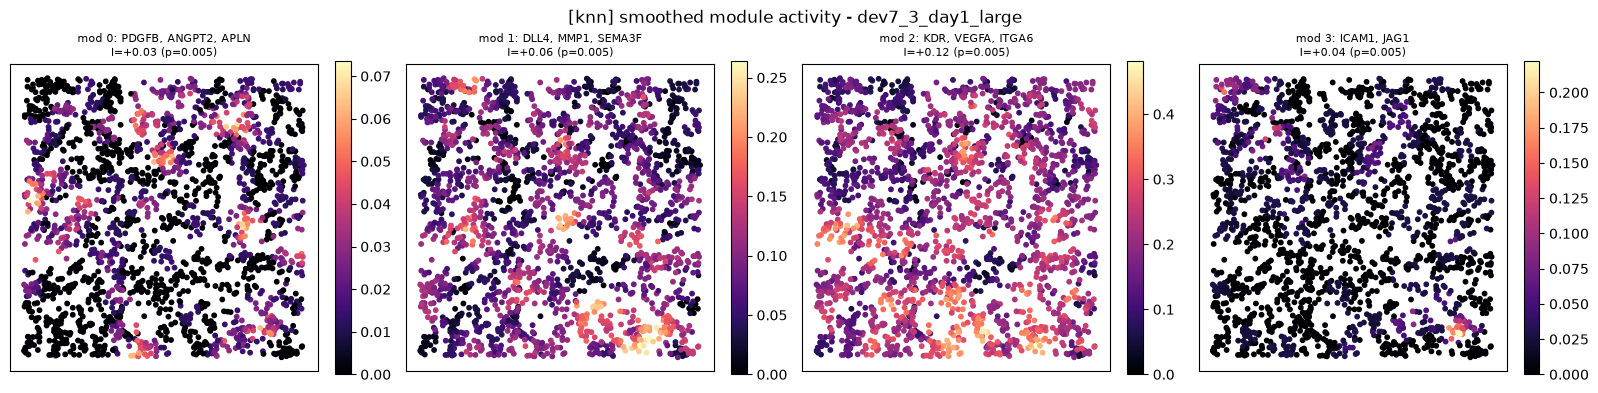

[knn] dev4_1_6h: 1504 cells, 13339 edges
    mod 0: PDGFB, ANGPT2, APLN         I=+0.085 p=0.005  patches= 10 max=   2 (frac 0.17)  -> intermixed
    mod 1: DLL4, MMP1, SEMA3F          I=+0.042 p=0.005  patches= 44 max=   6 (frac 0.08)  -> intermixed
    mod 2: KDR, VEGFA, ITGA6           I=+0.083 p=0.005  patches= 40 max=   9 (frac 0.14)  -> intermixed
    mod 3: ICAM1, JAG1                 I=+0.011 p=0.075  patches= 49 max=   6 (frac 0.06)  -> intermixed


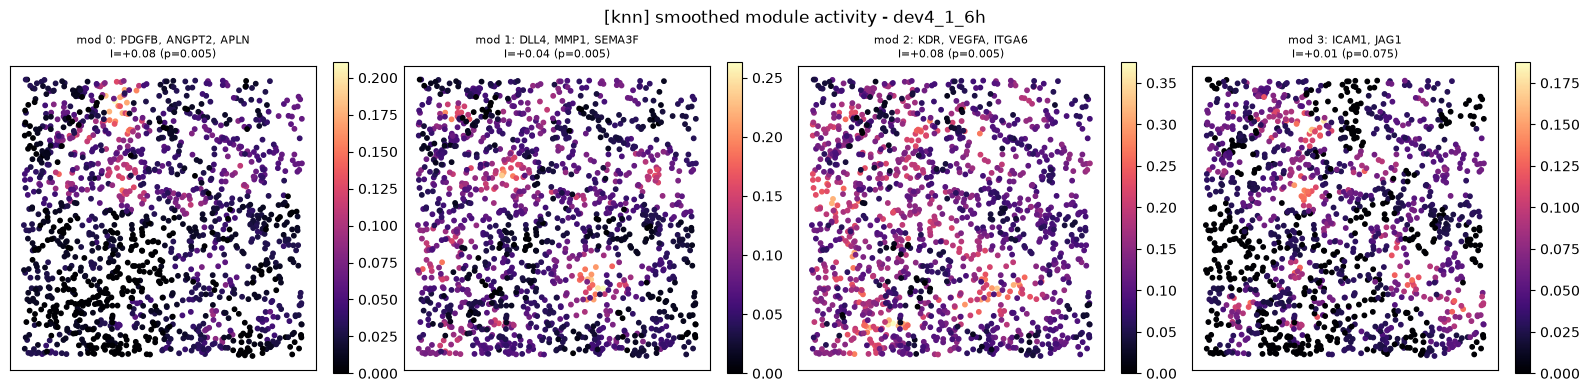

[delaunay] dev7_3_day1_large: 2350 cells, 4548 edges
    mod 0: PDGFB, ANGPT2, APLN         I=+0.024 p=0.060  patches=  4 max=   1 (frac 0.25)  -> intermixed
    mod 1: DLL4, MMP1, SEMA3F          I=+0.130 p=0.005  patches=115 max=   4 (frac 0.03)  -> patchy
    mod 2: KDR, VEGFA, ITGA6           I=+0.178 p=0.005  patches=178 max=   6 (frac 0.02)  -> patchy
    mod 3: ICAM1, JAG1                 I=+0.078 p=0.005  patches= 61 max=   6 (frac 0.09)  -> intermixed


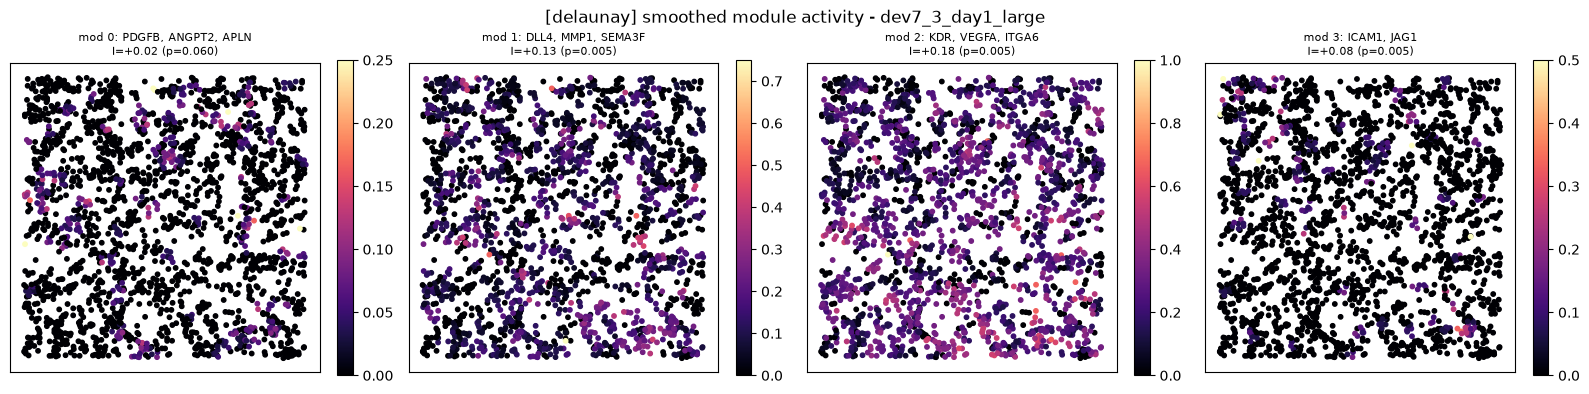

[delaunay] dev4_1_6h: 1504 cells, 2777 edges
    mod 0: PDGFB, ANGPT2, APLN         I=+0.101 p=0.005  patches= 11 max=   2 (frac 0.17)  -> patchy
    mod 1: DLL4, MMP1, SEMA3F          I=+0.086 p=0.005  patches= 63 max=   3 (frac 0.04)  -> intermixed
    mod 2: KDR, VEGFA, ITGA6           I=+0.150 p=0.005  patches= 53 max=   3 (frac 0.05)  -> patchy
    mod 3: ICAM1, JAG1                 I=+0.034 p=0.055  patches= 82 max=   5 (frac 0.05)  -> intermixed


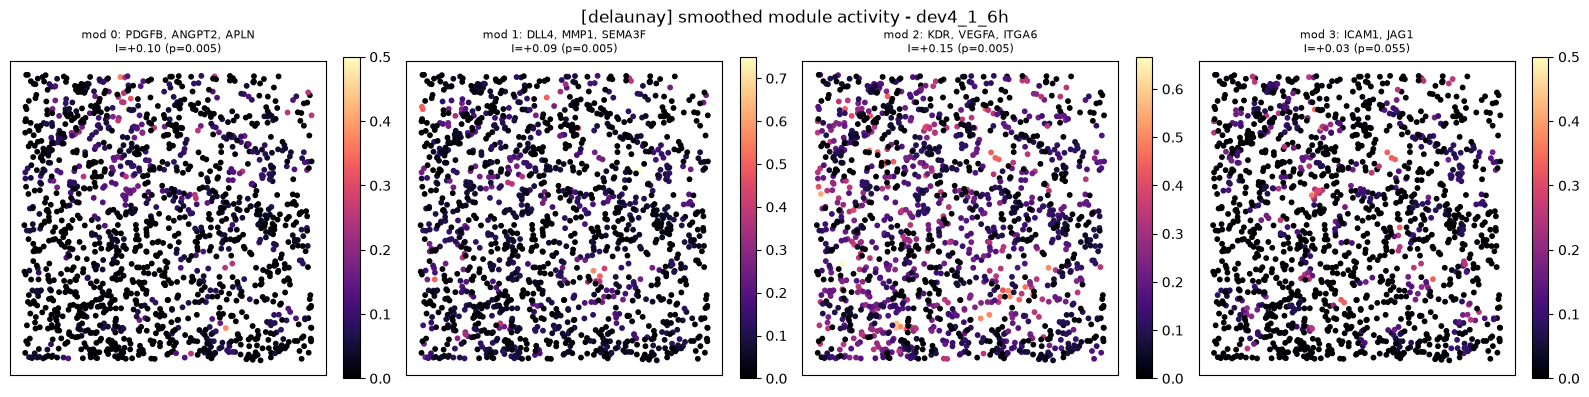


Moran's I (mean over the shown images) by neighbour method:
method                      delaunay    knn
module                                     
mod 0: PDGFB, ANGPT2, APLN     0.062  0.059
mod 1: DLL4, MMP1, SEMA3F      0.108  0.051
mod 2: KDR, VEGFA, ITGA6       0.164  0.101
mod 3: ICAM1, JAG1             0.056  0.024

Number of ON patches by neighbour method:
method                      delaunay   knn
module                                    
mod 0: PDGFB, ANGPT2, APLN       7.5   7.0
mod 1: DLL4, MMP1, SEMA3F       89.0  55.5
mod 2: KDR, VEGFA, ITGA6       115.5  50.5
mod 3: ICAM1, JAG1              71.5  47.5

Largest-patch fraction (share of ON cells in the biggest patch) by neighbour method:
method                      delaunay   knn
module                                    
mod 0: PDGFB, ANGPT2, APLN      0.21  0.21
mod 1: DLL4, MMP1, SEMA3F       0.03  0.11
mod 2: KDR, VEGFA, ITGA6        0.04  0.13
mod 3: ICAM1, JAG1              0.07  0.08


In [14]:
# ===== SPATIAL ORGANISATION OF THE GENE MODULES: TWO NEIGHBOUR DEFINITIONS + TWO PATCH METRICS =====
# Per-cell module activity = fraction of that module's genes ON. We then quantify how spatially
# structured each module is with TWO complementary descriptions, each computed on TWO neighbour
# graphs so they can be compared directly:
#   neighbour graph   "knn"      = fixed K_SPATIAL nearest neighbours (the original definition)
#                     "delaunay" = Delaunay adjacency pruned at RADIUS_UM (the definition used above)
#   patch metric      Moran's I  = continuous spatial autocorrelation of the activity
#                     patches    = binarise activity to ON/OFF, then count connected ON components
#                                  (approx. number of patches) and their sizes (approx. patch size)
module_cols = [module_labels[m] for m in range(len(communities))]
mod_act = pd.DataFrame({module_labels[m]: all_data[list(com)].mean(axis=1)
                        for m, com in enumerate(communities)}, index=all_data.index)

def undirected_pairs(coords, method, k=K_SPATIAL, cutoff=RADIUS_UM):
    """Unique undirected edges (local indices, i<j) for one image, by 'knn' or 'delaunay'."""
    n = len(coords)
    if method == "knn":
        _, idx = cKDTree(coords).query(coords, k=min(k + 1, n))
        idx = np.atleast_2d(idx)
        cols = idx[:, 1:] if idx.shape[1] > 1 else idx                      # drop self column
        pairs = np.column_stack([np.repeat(np.arange(n), cols.shape[1]), cols.ravel()])
    elif method == "delaunay":
        pairs = delaunay_neighbour_edges(coords, cutoff)
    else:
        raise ValueError(method)
    if len(pairs) == 0:
        return np.empty((0, 2), int)
    pairs = np.unique(np.sort(pairs, axis=1), axis=0)
    return pairs[pairs[:, 0] != pairs[:, 1]]

# Build (and cache) both neighbour graphs once per image so every downstream cell can reuse them.
GRAPHS = {method: {img: (sub.index.to_numpy(),
                         undirected_pairs(sub[["x_um", "y_um", "z_um"]].to_numpy(), method))
                   for img, sub in all_data.groupby(IMAGE_KEY)}
          for method in ("knn", "delaunay")}

def morans_i_edges(values, pairs, n_perm=200, seed=0):
    """Moran's I on an undirected edge list (row-uniform weights) + optional permutation p."""
    z = values - values.mean()
    ss = float(z @ z)
    if ss == 0 or len(pairs) == 0:
        return np.nan, np.nan
    n = len(values)
    src = np.concatenate([pairs[:, 0], pairs[:, 1]])                        # both directions
    dst = np.concatenate([pairs[:, 1], pairs[:, 0]])
    W = len(src)
    stat = (n / W) * float(z[src] @ z[dst]) / ss
    if not n_perm:
        return stat, np.nan
    rng = np.random.default_rng(seed)
    null = np.array([(n / W) * float((zp := rng.permutation(z))[src] @ zp[dst]) / ss
                     for _ in range(n_perm)])
    return stat, (np.sum(null >= stat) + 1) / (n_perm + 1)

def patch_stats(on_mask, pairs):
    """Connected ON components on the neighbour graph: number of patches and their sizes."""
    n = len(on_mask)
    on_idx = np.flatnonzero(on_mask)
    n_on = on_idx.size
    if n_on == 0:
        return dict(n_on=0, n_patches=0, mean_size=0.0, max_size=0, frac_largest=0.0)
    keep = on_mask[pairs[:, 0]] & on_mask[pairs[:, 1]]                      # ON-ON edges only
    e = pairs[keep]
    remap = np.full(n, -1); remap[on_idx] = np.arange(n_on)                 # compress to ON-only graph
    ei, ej = remap[e[:, 0]], remap[e[:, 1]]
    g = csr_matrix((np.ones(2 * len(ei)), (np.r_[ei, ej], np.r_[ej, ei])), shape=(n_on, n_on))
    n_comp, labels = connected_components(g, directed=False)
    sizes = np.bincount(labels)
    return dict(n_on=int(n_on), n_patches=int(n_comp), mean_size=float(sizes.mean()),
                max_size=int(sizes.max()), frac_largest=float(sizes.max() / n_on))

def knn_smooth_image(values, pairs, n):
    """Mean of each cell's neighbours + itself (for display only)."""
    if len(pairs) == 0:
        return values
    deg = np.bincount(np.concatenate([pairs[:, 0], pairs[:, 1]]), minlength=n).astype(float)
    s = np.zeros(n)
    np.add.at(s, pairs[:, 0], values[pairs[:, 1]])
    np.add.at(s, pairs[:, 1], values[pairs[:, 0]])
    return (s + values) / (deg + 1)

def module_spatial_summary(method, images=None, n_perm=200, on_thresh=0.5, plot=False, verbose=True):
    """Per-image, per-module Moran's I + ON-patch stats on the chosen neighbour graph.
    on_thresh = fraction of a module's genes that must be ON for a cell to count as ON."""
    graph = GRAPHS[method]
    if images is None:
        images = all_data[IMAGE_KEY].value_counts().index.tolist()
    A = mod_act[module_cols].to_numpy()
    records = []
    for image_name in images:
        pos, pairs = graph[image_name]
        n = len(pos); localA = A[pos]
        if verbose:
            print(f"[{method}] {image_name}: {n} cells, {len(pairs)} edges")
        moran = {}
        for j, col in enumerate(module_cols):
            vals = localA[:, j]
            I, p = morans_i_edges(vals, pairs, n_perm=n_perm)
            ps = patch_stats(vals >= on_thresh, pairs)
            moran[col] = (I, p)
            records.append(dict(method=method, image=image_name, module=col, moran_I=I, moran_p=p,
                                on_frac=float((vals >= on_thresh).mean()),
                                **{f"patch_{k}": v for k, v in ps.items()}))
            if verbose:
                verdict = "patchy" if (I > 0.1 and (np.isnan(p) or p < 0.05)) else "intermixed"
                print(f"    {col:34s} I={I:+.3f} p={p:.3f}  patches={ps['n_patches']:3d} "
                      f"max={ps['max_size']:4d} (frac {ps['frac_largest']:.2f})  -> {verdict}")
        if plot:
            sub = all_data.loc[pos]
            fig, axes = plt.subplots(1, len(module_cols), figsize=(4 * len(module_cols), 4), squeeze=False)
            for ax, (j, col) in zip(axes[0], enumerate(module_cols)):
                sm = knn_smooth_image(localA[:, j], pairs, n)
                I, p = moran[col]
                s = ax.scatter(sub["x_um"], sub["y_um"], c=sm, s=10, cmap="magma", vmin=0)
                ax.set_title(f"{col}\nI={I:+.2f} (p={p:.3f})", fontsize=8)
                ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
                plt.colorbar(s, ax=ax, fraction=0.046)
            fig.suptitle(f"[{method}] smoothed module activity - {image_name}")
            plt.tight_layout()
            # plt.savefig(r"z:\Bel\Jorge_SPACEFISH_Examples\Patchyness_Outputs" + f"\{method}_{image_name}.png")
            plt.show()
    return pd.DataFrame(records)

# ---- Compare the two neighbour definitions on the largest images ----
top_images = all_data[IMAGE_KEY].value_counts().head(2).index.tolist()
summary_knn = module_spatial_summary("knn", images=top_images, plot=True)
summary_delaunay = module_spatial_summary("delaunay", images=top_images, plot=True)
module_spatial = pd.concat([summary_knn, summary_delaunay], ignore_index=True)

# Side-by-side: does the patchy/intermixed verdict depend on the neighbour definition?
print("\nMoran's I (mean over the shown images) by neighbour method:")
print(module_spatial.pivot_table(index="module", columns="method", values="moran_I").round(3))
print("\nNumber of ON patches by neighbour method:")
print(module_spatial.pivot_table(index="module", columns="method", values="patch_n_patches").round(1))
print("\nLargest-patch fraction (share of ON cells in the biggest patch) by neighbour method:")
print(module_spatial.pivot_table(index="module", columns="method", values="patch_frac_largest").round(2))


[delaunay] mean Moran's I per module by timepoint (higher = patchy, ~0 = intermixed):
module     mod 0: PDGFB, ANGPT2, APLN  mod 1: DLL4, MMP1, SEMA3F  \
timepoint                                                          
6h                              0.079                      0.101   
day1                            0.058                      0.091   
day2                            0.100                      0.097   
day4                            0.139                      0.084   

module     mod 2: KDR, VEGFA, ITGA6  mod 3: ICAM1, JAG1  
timepoint                                                
6h                            0.112               0.038  
day1                          0.134               0.032  
day2                          0.115               0.044  
day4                          0.102               0.060   

Mean number of ON patches per module by timepoint (fewer = more coalesced):
module     mod 0: PDGFB, ANGPT2, APLN  mod 1: DLL4, MMP1, SEMA3F  \
timepoint  

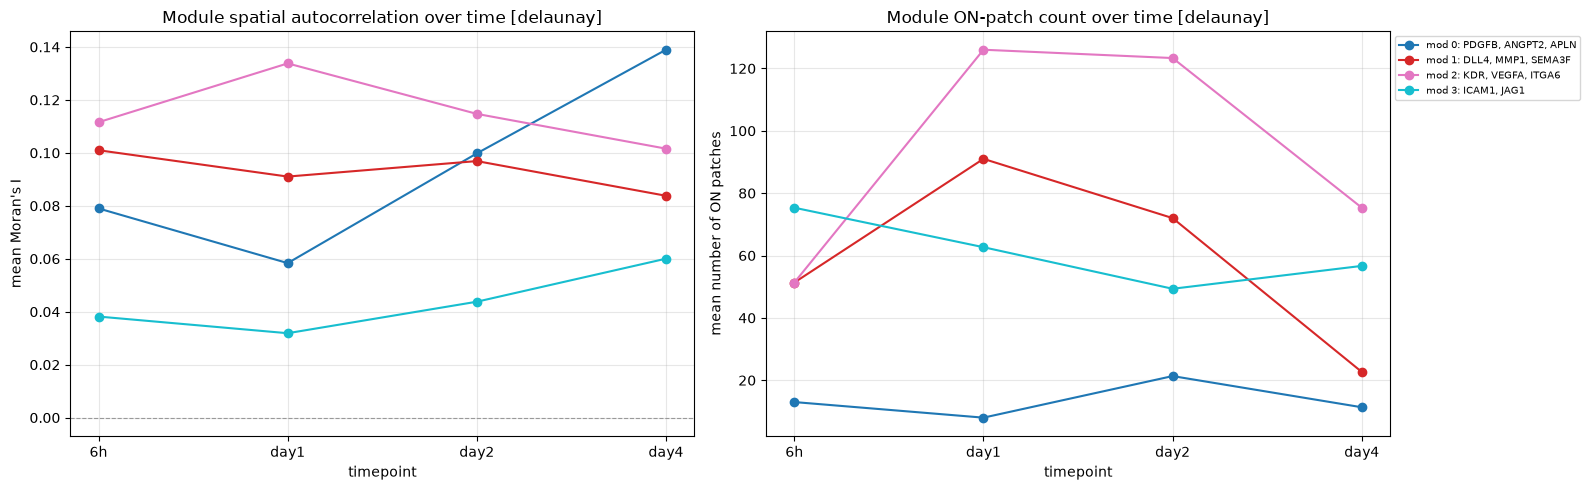

In [15]:
# ===== MODULE PATCHINESS OVER TIME (averaged across images per timepoint) =====
# For each image, Moran's I and the ON-patch count of every module (on PATCH_METHOD's graph),
# averaged over all images in a timepoint -> does each programme get more spatially organised
# (Moran's I up / fewer-but-bigger patches) as angiogenesis proceeds? Images with < MIN_CELLS
# cells are skipped. Switch PATCH_METHOD to "knn" to see the same trends on the old definition.
MIN_CELLS = 20
PATCH_METHOD = "delaunay"

big_images = [img for img, (pos, _) in GRAPHS[PATCH_METHOD].items() if len(pos) >= MIN_CELLS]
patch_over_time = module_spatial_summary(PATCH_METHOD, images=big_images, n_perm=0, plot=False, verbose=False)
patch_over_time["timepoint"] = [timepoint_of(img) for img in patch_over_time["image"]]

tp_present = [t for t in TIME_ORDER if t in set(patch_over_time["timepoint"])]
moran_by_time = (patch_over_time.pivot_table(index="timepoint", columns="module", values="moran_I")
                 .reindex(tp_present)[module_cols])
patches_by_time = (patch_over_time.pivot_table(index="timepoint", columns="module", values="patch_n_patches")
                   .reindex(tp_present)[module_cols])
images_per_tp = patch_over_time.groupby("timepoint")["image"].nunique().reindex(tp_present)

print(f"[{PATCH_METHOD}] mean Moran's I per module by timepoint (higher = patchy, ~0 = intermixed):")
print(moran_by_time.round(3), "\n")
print("Mean number of ON patches per module by timepoint (fewer = more coalesced):")
print(patches_by_time.round(1), "\n")
print("Images averaged per timepoint:", images_per_tp.to_dict())

module_cmap = plt.get_cmap("tab10", len(module_cols))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, col in enumerate(module_cols):
    axes[0].plot(range(len(tp_present)), moran_by_time[col].values, "o-", color=module_cmap(i), label=col)
    axes[1].plot(range(len(tp_present)), patches_by_time[col].values, "o-", color=module_cmap(i), label=col)
axes[0].axhline(0, color="0.6", lw=0.8, ls="--")
axes[0].set(xlabel="timepoint", ylabel="mean Moran's I", title=f"Module spatial autocorrelation over time [{PATCH_METHOD}]",
            xticks=range(len(tp_present)))
axes[1].set(xlabel="timepoint", ylabel="mean number of ON patches", title=f"Module ON-patch count over time [{PATCH_METHOD}]",
            xticks=range(len(tp_present)))
for ax in axes:
    ax.set_xticklabels(tp_present); ax.grid(alpha=0.3)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.tight_layout(); plt.show()


Mean module activity (fraction of module genes ON) by timepoint:
           mod 0: PDGFB, ANGPT2, APLN  mod 1: DLL4, MMP1, SEMA3F  \
timepoint                                                          
6h                              0.068                      0.110   
day1                            0.038                      0.147   
day2                            0.054                      0.142   
day4                            0.047                      0.076   

           mod 2: KDR, VEGFA, ITGA6  mod 3: ICAM1, JAG1  
timepoint                                                
6h                            0.201               0.055  
day1                          0.317               0.034  
day2                          0.359               0.034  
day4                          0.290               0.031  


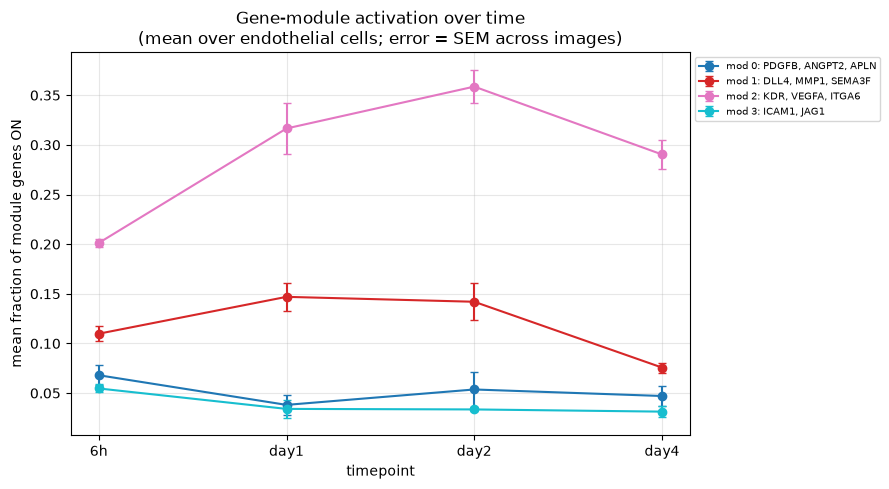

In [16]:
# ===== MODULE ACTIVATION OVER TIME (mean fraction of module genes ON) =====
# How strongly each module fires on average, per timepoint (complements the patchiness trend).
# Averaged per image first (mean of image means +/- SEM across images) so large images don't
# dominate. Endothelial cells with reads only - the lineage the modules describe.
endo_mod = mod_act.loc[(all_data["cell_type"] == "Endothelial") & all_data["has_reads"]].copy()
endo_mod["image"] = all_data.loc[endo_mod.index, IMAGE_KEY]
endo_mod["timepoint"] = [timepoint_of(img) for img in endo_mod["image"]]

image_means = endo_mod.groupby(["timepoint", "image"])[module_cols].mean()
tp_present = [t for t in TIME_ORDER if t in image_means.index.get_level_values("timepoint")]
activation_mean = image_means.groupby(level="timepoint")[module_cols].mean().reindex(tp_present)
activation_sem = image_means.groupby(level="timepoint")[module_cols].sem().reindex(tp_present)

print("Mean module activity (fraction of module genes ON) by timepoint:")
print(activation_mean.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(module_cols):
    ax.errorbar(range(len(tp_present)), activation_mean[col].values, yerr=activation_sem[col].values,
                fmt="o-", capsize=3, color=module_cmap(i), label=col)
ax.set(xlabel="timepoint", ylabel="mean fraction of module genes ON",
       title="Gene-module activation over time\n(mean over endothelial cells; error = SEM across images)",
       xticks=range(len(tp_present)))
ax.set_xticklabels(tp_present); ax.grid(alpha=0.3)
ax.legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.tight_layout(); plt.show()

In [8]:
print(repr(GENES)); print(repr(N_NICHES))

['CDH5', 'PECAM1', 'COL1A1', 'COL1A2', 'PDGFRB', 'VWF', 'DLL4', 'MMP1', 'SEMA3F', 'FLT1', 'ICAM1', 'JAG1', 'KDR', 'VEGFA', 'ITGA6', 'PDGFB', 'ANGPT2', 'APLN']
5
